# Machine Learning — Assignment 3

## Time Series Analysis using the MIT-BIH Arrhythmia Database

## Task 1 — Data Loading & Exploration

In [ ]:
# pip install wfdb
import wfdb 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


c:\Users\gemes\anaconda3\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\gemes\anaconda3\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


The MIT-BIH Arrhythmia Database is a publicly available ECG dataset from PhysioNet.
The signals are sampled at 360 Hz and each heartbeat is manually annotated by cardiologists.

For this assignment, we analyse 14 representative ECG records containing both normal rhythms and clinically significant arrhythmias.

In [3]:
# Records selected for the assigment which provide a representative mix of normal rhythm 
# and clinically significant arrhythmias:
records = ['100', '101', '105', '106','108', '109', '111', '112','115', '117', '119','201', '213', '219']
fs = 360
print("Number of records:", len(records))

Number of records: 14


In [4]:
# Following assigment instructions: 

# Load ECG signal data (record 100)
record = wfdb.rdrecord('100', pn_dir='mitdb') 
# Load annotation file ('atr') for the record 100. (Contains R-peak locations and beat labels).
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')
# Use channel 0 (MLII lead) from the ECG signal (as p_signal contains both ECG channels). 
signal = record.p_signal[:,0]

print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(ann.sample))

Signal shape: (650000,)
Sampling frequency: 360
Number of annotations: 2274


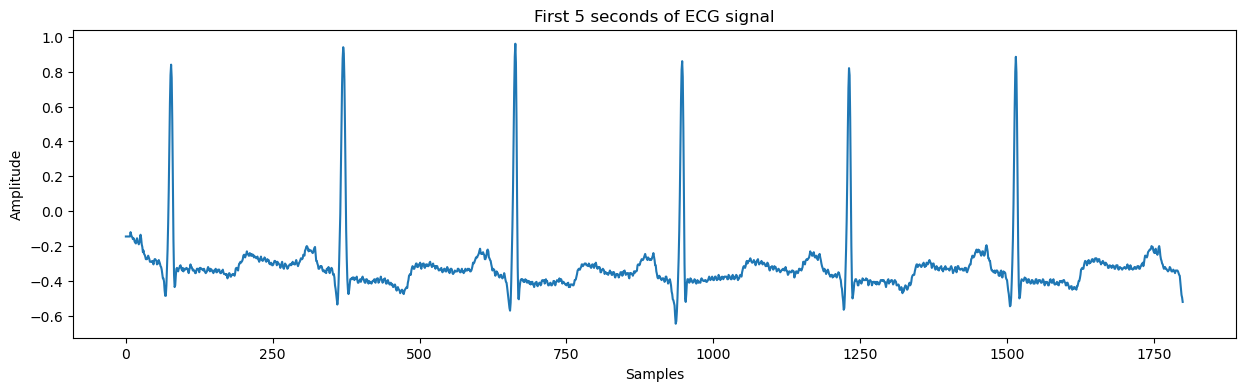

In [5]:
# Create a figure to visualize the ECG signal
plt.figure(figsize=(15,4))
plt.plot(signal[:1800]) # 1800 samples corresponds to approximately 5 seconds (at 360Hz).

plt.title("First 5 seconds of ECG signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

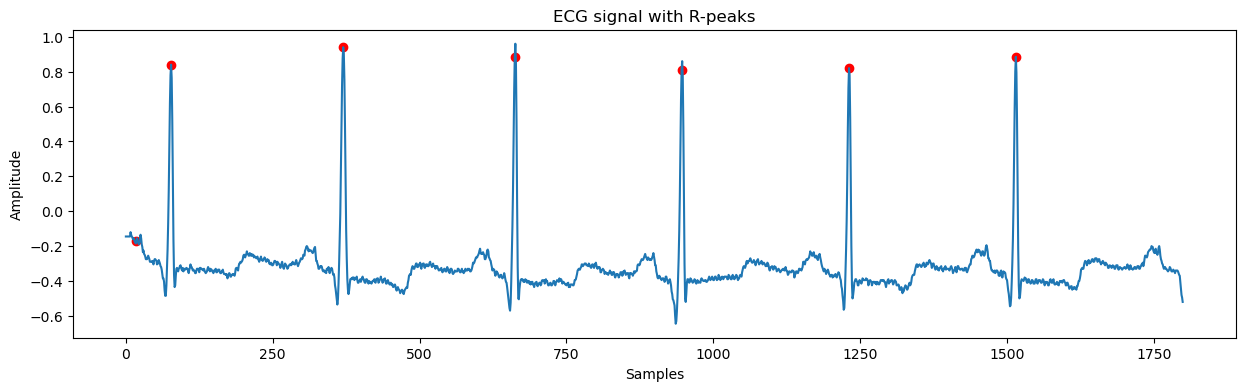

In [6]:
# Get R-peaks inside first 5 seconds, from the annotation file. 
peaks = ann.sample[ann.sample < 1800]

plt.figure(figsize=(15,4))
plt.plot(signal[:1800])
# Mark detected R-peaks with red dots
plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)
plt.title("ECG signal with R-peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

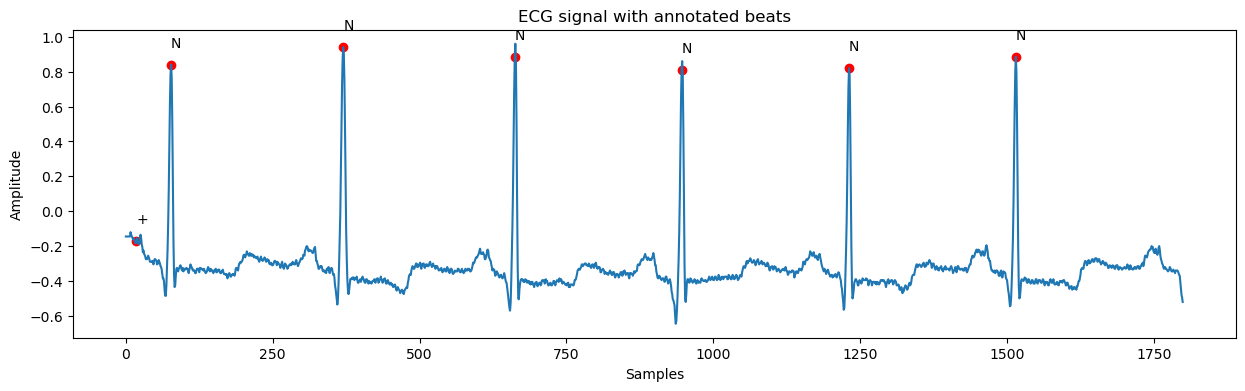

In [7]:
# Extract beat symbols
symbols = np.array(ann.symbol)[ann.sample < 1800]

plt.figure(figsize=(15,4))
plt.plot(signal[:1800])
# Mark detected R-peaks with red dots
plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)

# Add annotation labels above each R-peak
# p -> peak position
# s -> beat symbol (e.g., N, V, A)
for p, s in zip(peaks, symbols):
    plt.text(
        p,                 # x-coordinate
        signal[p] + 0.1,   # y-coordinate slightly above the peak
        s                  # annotation symbol
    )

plt.title("ECG signal with annotated beats")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [8]:
# Define a function that plots a selected ECG segment together with detected R-peaks and beat annotations

def plot_ecg_segment(record_id, start_sec=0, duration_sec=5):
    # Load record
    record = wfdb.rdrecord(record_id, pn_dir='mitdb')
    ann = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')  # Load annotation file
    signal = record.p_signal[:,0]                       # Use channel 0 (MLII lead)
    fs = record.fs                                      # Sampling frequency

    # Define segment (with the start and end sample indices)
    start = int(start_sec * fs)
    end = int((start_sec + duration_sec) * fs)
    segment = signal[start:end]

    # Select only R-peaks located within the selected segment
    peaks = ann.sample[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    # Extract beat symbols corresponding to the selected peaks
    symbols = np.array(ann.symbol)[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    time = np.arange(start, end) / fs

    # Plot
    plt.figure(figsize=(15,4))
    plt.plot(time, segment)
    plt.scatter(
        peaks / fs,
        signal[peaks],
        color='red'
    )
    # Add beat symbols
    for p, s in zip(peaks, symbols):
        plt.text(
            p / fs,
            signal[p] + 0.1,
            s
        )

    plt.title(f"MIT-BIH Record {record_id}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

    plt.show()

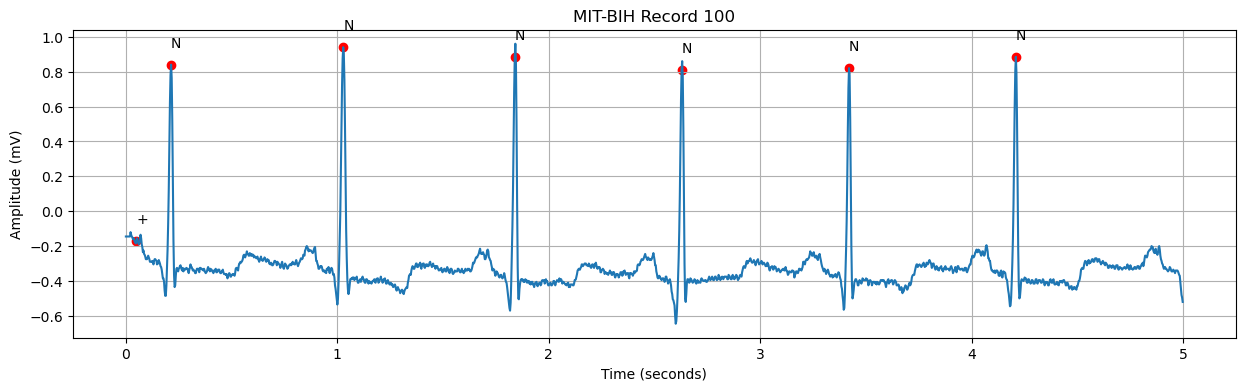

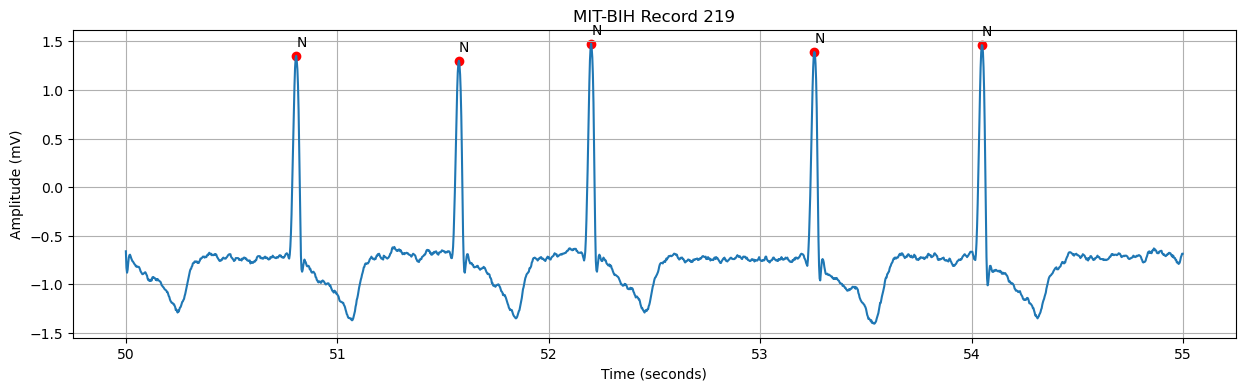

In [9]:
# Plot at least TWO records. 
plot_ecg_segment('100', start_sec=0)
plot_ecg_segment('219', start_sec=50)

#### ECG Signal Exploration

The ECG recordings were loaded directly from PhysioNet using the wfdb library.
For visual exploration, 5-second ECG segments were plotted together with the annotated R-peak locations provided by the dataset.

Record 100 mainly shows normal sinus rhythm, while record 219 contains a larger number of arrhythmic beats and rhythm variability.

In [10]:
label_map = {

    # Normal beats
    'N': 'N',
    '.': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # Supraventricular ectopic beats
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # Ventricular ectopic beats
    'V': 'V',
    'E': 'V'
}

In [11]:
all_labels = []

# Loop through all selected MIT-BIH records
for rec in records:
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb') # Load annotation file
    
    # Map original beat symbols into the 3 AAMI classes (using the previous label_map): 
        # N = Normal
        # S = Supraventricular ectopic
        # V = Ventricular ectopic
    mapped_labels = [
        label_map[symbol]
        for symbol in ann.symbol
        if symbol in label_map #(ignores symbols not included in label_map)
    ]
    # Add mapped labels to global list
    all_labels.extend(mapped_labels)

# Count number of beats per class
class_counts = Counter(all_labels)
# Display class distribution
print(class_counts)

Counter({'N': 28412, 'V': 1544, 'S': 206})


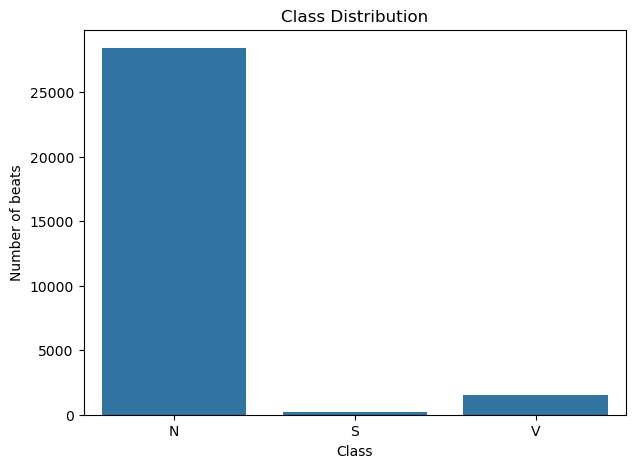

In [12]:
plt.figure(figsize=(7,5))
# Plot class distribution
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of beats")

plt.show()

#### Class Imbalance Discussion

The dataset is strongly imbalanced, with normal beats (N) representing the majority of samples, while supraventricular (S) and ventricular (V) beats are much less frequent.

This imbalance may bias machine learning models towards the majority class. A classifier predicting mostly normal beats could achieve high accuracy while failing to correctly detect clinically important arrhythmias.

For this reason, macro F1-score is more informative than accuracy in this task. Macro F1 evaluates each class equally regardless of frequency, making it more sensitive to minority-class performance.

This is particularly important in clinical applications, where false negatives in ventricular arrhythmias may have serious consequences for patient safety.

In [13]:
# Class Balanced?
total_beats = sum(class_counts.values())
for cls, count in class_counts.items():
    percentage = (count / total_beats) * 100
    print(f"{cls}: {count} beats ({percentage:.2f}%)")

N: 28412 beats (94.20%)
S: 206 beats (0.68%)
V: 1544 beats (5.12%)


## Task 2 — Preprocessing & Feature Engineering

In [14]:
# Load annotations for all 14 records. Apply label_map to map raw symbols to N, S, or V. 
# Discard beats with unmapped symbols and report the count discarded. 
all_labels = []
discarded_count = 0

for rec in records:
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    for symbol in ann.symbol:
        if symbol in label_map:
            all_labels.append(label_map[symbol])
        else: # symbols not included in label_map
            discarded_count += 1

# Count class distribution
class_counts = Counter(all_labels)

print("Class distribution (N, S, V):")
print(class_counts)

print("\nTotal discarded beats:")
print(discarded_count)

Class distribution (N, S, V):
Counter({'N': 28412, 'V': 1544, 'S': 206})

Total discarded beats:
1057


Approximately 3.4% of annotations were discarded due to being outside the AAMI N/S/V classes. This is expected due to the presence of auxiliary and non-beat annotations in the MIT-BIH dataset. The resulting dataset remains highly imbalanced, with normal beats dominating.

### Feature Engineering

Extract all 8 features per beat as specified in the Feature Extraction section. Handle the 
first-beat edge case and document your approach.

CONSIDERATIONS: For the first beat in each record, RR-based features cannot be computed due to missing previous beats. We imputed RR_current, RR_prev, and RR_local_mean using the mean of the first available RR intervals (first 5 beats when available). This preserves physiological consistency while avoiding bias from zero or NaN initialization.

In [15]:
# Define Helper functions: 

# QRS duration (50% threshold method)
def compute_qrs_duration(signal, r_peak):
    r_amp = signal[r_peak]
    threshold = 0.5 * r_amp

    # From the r-peak location; move to the left until signal drops below 50%. 
    left = r_peak
    while left > 0 and signal[left] > threshold:
        left -= 1
    # From the r-peak location; move to the right until signal drops below 50%. 
    right = r_peak
    while right < len(signal) and signal[right] > threshold:
        right += 1
    
    # Width of the spike (QRS)
    qrs_duration = right - left

    return qrs_duration, r_amp


# Energy 
def compute_energy(signal, r_peak, window=20):
    # pick a small region around R-peak (given the window =20, ~40 samples around the beat). 
    start = max(0, r_peak - window)
    end = min(len(signal), r_peak + window)
    # square the signal and sum everything to obtain the energy (activity). 
    energy = np.sum(signal[start:end] ** 2)
    return energy

# ST segment
def compute_st_mean(signal, r_peak):
    # define ST window ( It was specified to be +40 to +120 samples)
    start = r_peak + int(0.11 * fs)   # +40 samples
    end = r_peak + int(0.33 * fs)     # +120 samples
    # safety check
    if end >= len(signal):
        return np.nan

    # Compute average signal
    av_s = np.mean(signal[start:end])
    return av_s
 

In [16]:
# Feature extraction loop

all_features = []

# Loop through each ECG record
for rec in records:

    # Load ECG signal and annotations for this record
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
    signal = record.p_signal[:, 0]  # Extract the ECG signal
    r_peaks = ann.sample            # R-peak locations
    symbols = ann.symbol            # Beat labels

    # RR intervals (difference between R-peaks)
    rr_intervals = np.diff(r_peaks) / fs * 1000 # RR intervals are in milliseconds (convert from samples).

    # Handle first-beat edge case
    # The first beat has no previous RR interval, so we approximate using the mean of the first few RR intervals
    
    if len(rr_intervals) >= 5:
        first_rr_mean = np.mean(rr_intervals[:5])
    else:
        first_rr_mean = np.mean(rr_intervals)

    # Loop over each beat (R-peak) --> we will compute 8 features per beat. 
    for i in range(len(r_peaks)):
        r = r_peaks[i]

        # RR FEATURES
        if i == 0:
            # First beat: no history → use estimated baseline
            rr_current = first_rr_mean
            rr_prev = first_rr_mean
            rr_local_mean = first_rr_mean

        elif i == 1:
            # Second beat: only one RR available
            rr_current = (r_peaks[i] - r_peaks[i-1]) / fs * 1000
            rr_prev = rr_current
            rr_local_mean = rr_current

        else:
            # Normal case: enough history available
            rr_current = (r_peaks[i] - r_peaks[i-1]) / fs * 1000
            rr_prev = (r_peaks[i-1] - r_peaks[i-2]) / fs * 1000

            start_local = max(0, i - 4)
            rr_local_mean = np.mean(
                np.diff(r_peaks[start_local:i + 1]) / fs * 1000
            )

        # RR ratio (avoid division by zero)
        if rr_local_mean != 0:
            rr_ratio = rr_current / rr_local_mean
        else:
            rr_ratio = 0

        # MORPHOLOGICAL FEATURES
        qrs_duration, r_amp = compute_qrs_duration(signal, r)
        qrs_energy = compute_energy(signal, r)
        st_mean = compute_st_mean(signal, r)

        # LABEL
        if symbols[i] not in label_map: #Should not happen because previously delated, but to be sure. 
            continue

        label = label_map[symbols[i]]
        all_features.append([
            rr_current,
            rr_prev,
            rr_ratio,
            rr_local_mean,
            r_amp,
            qrs_duration,
            qrs_energy,
            st_mean,
            label,
            rec
        ])

In [17]:
# Build DataFrame
columns = [
    "RR_current",
    "RR_prev",
    "RR_ratio",
    "RR_local_mean",
    "R_amplitude",
    "QRS_duration",
    "QRS_energy",
    "ST_mean",
    "label",
    "record_id"
]
df = pd.DataFrame(all_features, columns=columns)
print(df.shape)
df.head()

(30162, 10)


,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,label,record_id
0,163.888889,163.888889,1.000000,163.888889,0.840,6,6.689325,-0.344367,N,100
1,813.888889,163.888889,1.664773,488.888889,0.940,8,8.803875,-0.412785,N,100
2,811.111111,813.888889,1.360248,596.296296,0.885,6,8.992275,-0.397532,N,100
3,788.888889,811.111111,1.224138,644.444444,0.810,6,9.357875,-0.368165,N,100
4,791.666667,788.888889,0.987868,801.388889,0.820,6,7.912075,-0.406899,N,100


After computing the 8 features in Task 2, produce a correlation heatmap of the feature 
matrix. Identify and briefly discuss the most strongly correlated pairs. 

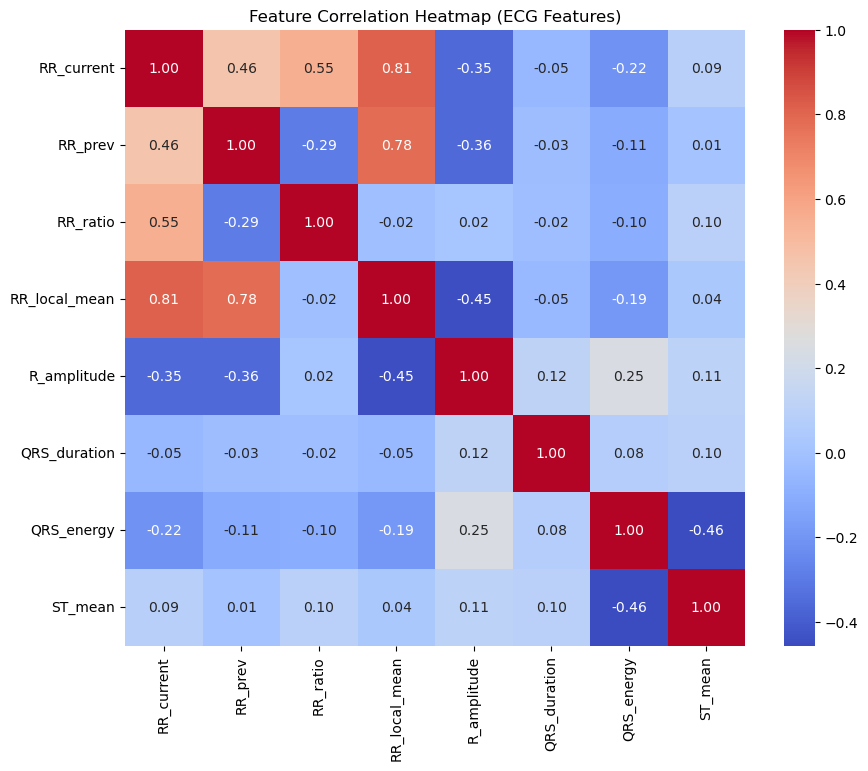

In [ ]:
# Select only feature columns (exclude label + record_id)
feature_cols = [
    "RR_current",
    "RR_prev",
    "RR_ratio",
    "RR_local_mean",
    "R_amplitude",
    "QRS_duration",
    "QRS_energy",
    "ST_mean"
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (ECG Features)")
plt.show()

The most strongly correlated feature pairs in the dataset are mainly within the RR-related group. The strongest correlation is between RR_current and RR_local_mean (0.81), followed closely by RR_prev and RR_local_mean (0.78), indicating that the local mean is heavily influenced by both current and previous RR intervals. Additionally, RR_current and RR_ratio (0.55) and RR_current and RR_prev (0.46) show moderate positive correlations, reflecting the temporal dependence between consecutive heartbeats. These strong relationships suggest that RR-based features contain overlapping information and describe the same underlying heart rate dynamics.

Next steps: 
- Train/test split: apply a stratified 80/20 random split (random_state=42). Verify that 
class proportions are preserved in both splits and report the beat counts per class in 
each set. 
- Scaling: apply StandardScaler to the 8 features. Fit on the training set only and 
transform both train and test sets. 

In [19]:
X = df[feature_cols] # only feature columns (exclude label + record_id)
y = df["label"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      #stratified 80/20 random split
    random_state=42,    #random_state=42
    stratify=y
)

# Scale : StandardScaler standardizes each feature as 
# z = (x - mean) / standard deviation   ; After scaling: (mean ≈ 0 and std ≈ 1)
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train) #fit_transform() = fit() + transform()
# Transform test data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

In [20]:
# class proportions are preserved in both splits? 
distribution_df = pd.DataFrame({
    "Train Count": y_train.value_counts(),
    "Train Proportion": y_train.value_counts(normalize=True),
    "Test Count": y_test.value_counts(),
    "Test Proportion": y_test.value_counts(normalize=True)
})
# round proportions for readability
distribution_df["Train Proportion"] = distribution_df["Train Proportion"].round(3)
distribution_df["Test Proportion"] = distribution_df["Test Proportion"].round(3)

# Display table
print(distribution_df)

       Train Count  Train Proportion  Test Count  Test Proportion
label                                                            
N            22729             0.942        5683            0.942
V             1235             0.051         309            0.051
S              165             0.007          41            0.007


The stratified 80/20 split preserved the original class distribution across both training and test sets, as evidenced by nearly identical class proportions. However, the dataset remains highly imbalanced, with normal beats accounting for approximately 94% of all samples, while ventricular and supraventricular beats are significantly underrepresented.

In [21]:
# Construct the sliding window dataset for RNN and LSTM: for each beat at position i ≥ 10, 
# create a sample consisting of the feature vectors for beats i−9 through i (shape: 10 × 8) 
# with label equal to the class of beat i. Apply the same 80/20 split. 

# 1. Build sliding windows (FULL dataset first)

# Each sample will contain: beat i-9 ... beat i. (Total beats per sample = 10). 
window_size = 10

# Lists to store sequences and labels
X_seq = []
y_seq = []
# Extract features and labels from DataFrame
features = df[feature_cols].values
labels = df["label"].values

# 2. Create sliding windows (sequence length: (10, 8)).
for i in range(window_size - 1, len(df)):
    # Extract 10 consecutive beats
    sequence = features[i - window_size + 1 : i + 1]
    # Label corresponds to current beat
    label = labels[i]
    # Store sequence and label
    X_seq.append(sequence)
    y_seq.append(label)

# 3. Convert lists to NumPy arrays
X_seq = np.array(X_seq)   # shape: (n_samples, 10, 8)
y_seq = np.array(y_seq)
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

# 4. Train/test split
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

print("\nTRAIN SET")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

print("\nTEST SET")
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_seq shape: (30153, 10, 8)
y_seq shape: (30153,)

TRAIN SET
X_train_seq shape: (24122, 10, 8)
y_train_seq shape: (24122,)

TEST SET
X_test_seq shape: (6031, 10, 8)
y_test_seq shape: (6031,)


The sliding-window dataset was successfully constructed for sequential deep learning models, producing input sequences of shape (10, 8) and preserving class balance through an 80/20 stratified train-test split, making the data ready for RNN and LSTM training.

This format is required because RNN and LSTM models learn temporal patterns from sequences, not from individual beats. Each sample therefore contains 10 consecutive beats (`10 × 8`) so the model can use information from previous heartbeats to classify the current beat. The first 9 beats cannot form a complete sequence, so they are excluded.



## Task 3 — 